Adarsh Gupta\
2547106

In [9]:

# TASK 1 — Data profile and first-impression inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

AQI_PATH = 'city_day.csv'
CROP_PATH = 'crop_production.csv'

aqi_raw = pd.read_csv(AQI_PATH)
crop_raw = pd.read_csv(CROP_PATH)

# Work on copies throughout the notebook
aqi = aqi_raw.copy()
crop = crop_raw.copy()

def profile_df(df, name):
    display(Markdown(f"## Dataset Profile: `{name}`"))
    display(Markdown(f"**Rows:** {df.shape[0]:,}  \n**Columns:** {df.shape[1]:,}"))
    display(Markdown("### Column data types and non-null counts"))
    info_table = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.astype(str).values,
        'Non-Null Count': df.notna().sum().values,
        'Missing Count': df.isna().sum().values,
        'Missing %': (df.isna().mean().values * 100).round(2)
    })
    display(info_table)
    display(Markdown("### First 5 records"))
    display(df.head())
    display(Markdown("### Numeric summary"))
    display(df.describe().T)
    display(Markdown("### Categorical summary"))
    display(df.describe(include='object').T)
    display(Markdown(f"### Exact duplicate rows: **{df.duplicated().sum():,}**"))

profile_df(aqi, 'city_day.csv')
profile_df(crop, 'crop_production.csv')

display(Markdown("## Task 1 Observation / Concern"))
display(Markdown("""
- The AQI dataset has substantial missing values in several pollutant columns, especially PM10, NH3, Xylene, AQI, and AQI_Bucket.
- The AQI dataset is city-date level, while the crop dataset is state-year-district-crop level. They cannot be merged directly without aggregation.
- The AQI file does not contain a State column, so a city-to-state mapping is required before any state-wise merge.
- The crop dataset contains missing Production values, and Production is central to crop output analysis, so those rows need careful treatment.
"""))


## Dataset Profile: `city_day.csv`

**Rows:** 29,531  
**Columns:** 16

### Column data types and non-null counts

,Column,Data Type,Non-Null Count,Missing Count,Missing %
0,City,object,29531,0,0.00
1,Date,object,29531,0,0.00
2,PM2.5,float64,24933,4598,15.57
3,PM10,float64,18391,11140,37.72
4,NO,float64,25949,3582,12.13
5,NO2,float64,25946,3585,12.14
6,NOx,float64,25346,4185,14.17
7,NH3,float64,19203,10328,34.97
8,CO,float64,27472,2059,6.97
9,SO2,float64,25677,3854,13.05


### First 5 records

...

### Categorical summary

,count,unique,top,freq
State_Name,246091,33,Uttar Pradesh,33306
District_Name,246091,646,BIJAPUR,945
Season,246091,6,Kharif,95951
Crop,246091,124,Rice,15104


### Exact duplicate rows: **0**

## Task 1 Observation / Concern


- The AQI dataset has substantial missing values in several pollutant columns, especially PM10, NH3, Xylene, AQI, and AQI_Bucket.
- The AQI dataset is city-date level, while the crop dataset is state-year-district-crop level. They cannot be merged directly without aggregation.
- The AQI file does not contain a State column, so a city-to-state mapping is required before any state-wise merge.
- The crop dataset contains missing Production values, and Production is central to crop output analysis, so those rows need careful treatment.


In [10]:

# TASK 2 — Missing value treatment

from IPython.display import display, Markdown

# Start from raw copies for this cleaning stage
aqi_clean = aqi_raw.copy()
crop_clean = crop_raw.copy()

before_aqi_nulls = pd.DataFrame({
    'Missing Count': aqi_clean.isna().sum(),
    'Missing %': (aqi_clean.isna().mean() * 100).round(2)
}).query('`Missing Count` > 0')

before_crop_nulls = pd.DataFrame({
    'Missing Count': crop_clean.isna().sum(),
    'Missing %': (crop_clean.isna().mean() * 100).round(2)
}).query('`Missing Count` > 0')

display(Markdown("## Before Treatment — AQI Missing Values"))
display(before_aqi_nulls)
display(Markdown("## Before Treatment — Crop Missing Values"))
display(before_crop_nulls)

# Convert date and basic text normalization before imputation
aqi_clean['Date'] = pd.to_datetime(aqi_clean['Date'], errors='coerce')
for col in ['City', 'AQI_Bucket']:
    if col in aqi_clean.columns:
        aqi_clean[col] = aqi_clean[col].astype('string').str.strip()

for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    crop_clean[col] = crop_clean[col].astype('string').str.strip()

# AQI treatment strategy
# - Drop Xylene because more than half of it is missing, making imputation weak.
# - Drop rows with missing AQI because AQI is the main analysis variable and target-like value.
# - Fill missing AQI_Bucket after AQI-based row removal using mode within city, then global mode.
# - Fill pollutant columns using city-wise median first, then global median.

if 'Xylene' in aqi_clean.columns:
    aqi_clean = aqi_clean.drop(columns=['Xylene'])

aqi_clean = aqi_clean.dropna(subset=['Date', 'AQI'])

numeric_pollutants = [c for c in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene'] if c in aqi_clean.columns]
for col in numeric_pollutants:
    aqi_clean[col] = aqi_clean[col].fillna(aqi_clean.groupby('City')[col].transform('median'))
    aqi_clean[col] = aqi_clean[col].fillna(aqi_clean[col].median())

if 'AQI_Bucket' in aqi_clean.columns:
    city_mode_bucket = aqi_clean.groupby('City')['AQI_Bucket'].transform(lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA)
    aqi_clean['AQI_Bucket'] = aqi_clean['AQI_Bucket'].fillna(city_mode_bucket)
    aqi_clean['AQI_Bucket'] = aqi_clean['AQI_Bucket'].fillna(aqi_clean['AQI_Bucket'].mode().iloc[0])

# Crop treatment strategy
# - Production is central to the output/yield analysis.
# - Missing Production is low in percentage, and imputing it may invent fake agricultural output.
# - Drop those rows rather than fabricate production values.

crop_clean = crop_clean.dropna(subset=['Production'])

# Ensure numeric columns are numeric
for col in ['Crop_Year', 'Area', 'Production']:
    crop_clean[col] = pd.to_numeric(crop_clean[col], errors='coerce')
crop_clean = crop_clean.dropna(subset=['Crop_Year', 'Area', 'Production'])

after_aqi_nulls = pd.DataFrame({
    'Missing Count': aqi_clean.isna().sum(),
    'Missing %': (aqi_clean.isna().mean() * 100).round(2)
})
after_crop_nulls = pd.DataFrame({
    'Missing Count': crop_clean.isna().sum(),
    'Missing %': (crop_clean.isna().mean() * 100).round(2)
})

display(Markdown("## Treatment Strategy"))
display(Markdown("""
### AQI dataset
- **Xylene:** Dropped because its missing percentage is very high, so imputation would be unreliable.
- **AQI:** Rows with missing AQI were removed because AQI is the main variable used for pollution analysis.
- **Pollutant columns:** Missing values were filled using city-wise median first, then global median. Median is preferred because pollution data is usually skewed and affected by extreme readings.
- **AQI_Bucket:** Filled using the most common bucket within the same city, then global mode if needed.

### Crop dataset
- **Production:** Rows with missing Production were removed. Production is the main agricultural output variable, and imputing it could create artificial crop output values.
"""))

display(Markdown("## After Treatment — AQI Missing Values"))
display(after_aqi_nulls[after_aqi_nulls['Missing Count'] > 0])
display(Markdown("## After Treatment — Crop Missing Values"))
display(after_crop_nulls[after_crop_nulls['Missing Count'] > 0])

display(Markdown(f"**AQI rows after treatment:** {len(aqi_clean):,}  \n**Crop rows after treatment:** {len(crop_clean):,}"))


## Before Treatment — AQI Missing Values

,Missing Count,Missing %
PM2.5,4598,15.57
PM10,11140,37.72
NO,3582,12.13
NO2,3585,12.14
NOx,4185,14.17
NH3,10328,34.97
CO,2059,6.97
SO2,3854,13.05
O3,4022,13.62
Benzene,5623,19.04


## Before Treatment — Crop Missing Values

,Missing Count,Missing %
Production,3730,1.52


## Treatment Strategy

...

## After Treatment — AQI Missing Values

,Missing Count,Missing %


## After Treatment — Crop Missing Values

,Missing Count,Missing %


**AQI rows after treatment:** 24,850  
**Crop rows after treatment:** 242,361

In [11]:

# TASK 3 — Standardise state names and remove duplicates

from IPython.display import display, Markdown
pd.set_option('display.max_colwidth', None)

# AQI data has City but no State, so we add State through a documented mapping.
city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

def standardise_state_name(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    replacements = {
        'Jammu and Kashmir ': 'Jammu and Kashmir',
        'Telangana ': 'Telangana',
        'Orissa': 'Odisha',
        'Delhi': 'Delhi'
    }
    return replacements.get(s, s)

before_aqi_rows = len(aqi_clean)
before_crop_rows = len(crop_clean)
before_aqi_dups = aqi_clean.duplicated().sum()
before_crop_dups = crop_clean.duplicated().sum()

aqi_clean['State'] = aqi_clean['City'].map(city_to_state)
aqi_clean['State'] = aqi_clean['State'].apply(standardise_state_name)
crop_clean['State_Name'] = crop_clean['State_Name'].apply(standardise_state_name)

# Remove exact duplicates
aqi_clean = aqi_clean.drop_duplicates()
crop_clean = crop_clean.drop_duplicates()

# Also remove duplicate AQI records for the same City-Date by averaging numeric values and keeping first categorical values.
num_cols = aqi_clean.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in aqi_clean.columns if c not in num_cols + ['Date']]
agg_dict = {c: 'mean' for c in num_cols}
agg_dict.update({c: 'first' for c in cat_cols})
aqi_clean = aqi_clean.groupby(['City', 'Date'], as_index=False).agg(agg_dict)

after_aqi_rows = len(aqi_clean)
after_crop_rows = len(crop_clean)
after_aqi_dups = aqi_clean.duplicated().sum()
after_crop_dups = crop_clean.duplicated().sum()

unmapped_cities = sorted(aqi_clean.loc[aqi_clean['State'].isna(), 'City'].unique())
common_states = sorted(set(aqi_clean['State'].dropna()) & set(crop_clean['State_Name'].dropna()))

fixes = pd.DataFrame({
    'Issue Found': [
        'AQI dataset lacked a State column',
        'Crop state names had trailing spaces such as Jammu and Kashmir and Telangana',
        'AQI records could contain repeated City-Date rows',
        'Exact duplicate rows could distort counts and averages'
    ],
    'Fix Applied': [
        'Mapped each AQI city to its Indian state using a city-to-state dictionary',
        'Applied strip() and a standard replacement function to state names',
        'Grouped by City and Date, averaging numeric readings and keeping first categorical labels',
        'Removed exact duplicates using drop_duplicates()'
    ]
})

display(Markdown("## Inconsistencies Found and Fixes Applied"))
display(fixes)

display(Markdown("## Duplicate / Record Count Evidence"))
display(pd.DataFrame({
    'Dataset': ['AQI', 'Crop'],
    'Rows Before': [before_aqi_rows, before_crop_rows],
    'Exact Duplicates Before': [before_aqi_dups, before_crop_dups],
    'Rows After': [after_aqi_rows, after_crop_rows],
    'Exact Duplicates After': [after_aqi_dups, after_crop_dups]
}))

display(Markdown(f"**Unmapped AQI cities:** {unmapped_cities if unmapped_cities else 'None'}"))
display(Markdown(f"**Number of common states available for future merge:** {len(common_states)}"))
display(Markdown(", ".join(common_states)))


## Inconsistencies Found and Fixes Applied

,Issue Found,Fix Applied
0,AQI dataset lacked a State column,Mapped each AQI city to its Indian state using a city-to-state dictionary
1,Crop state names had trailing spaces such as Jammu and Kashmir and Telangana,Applied strip() and a standard replacement function to state names
2,AQI records could contain repeated City-Date rows,"Grouped by City and Date, averaging numeric readings and keeping first categorical labels"
3,Exact duplicate rows could distort counts and averages,Removed exact duplicates using drop_duplicates()


## Duplicate / Record Count Evidence

,Dataset,Rows Before,Exact Duplicates Before,Rows After,Exact Duplicates After
0,AQI,24850,0,24850,0
1,Crop,242361,0,242361,0


**Unmapped AQI cities:** None

**Number of common states available for future merge:** 20

Andhra Pradesh, Assam, Bihar, Chandigarh, Gujarat, Haryana, Jharkhand, Karnataka, Kerala, Madhya Pradesh, Maharashtra, Meghalaya, Mizoram, Odisha, Punjab, Rajasthan, Tamil Nadu, Telangana, Uttar Pradesh, West Bengal

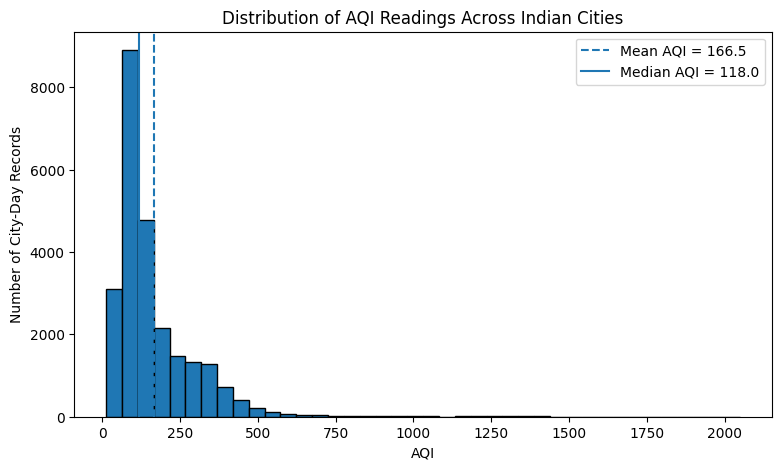

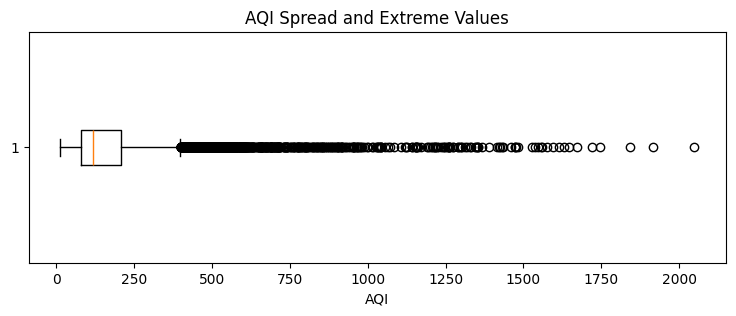

,AQI Bucket,Count
0,Moderate,8829
1,Satisfactory,8224
2,Poor,2781
3,Very Poor,2337
4,Good,1341
5,Severe,1338


## Plot Justification and Observations


A histogram was chosen because it shows where most AQI readings cluster. A boxplot was also used because it makes extreme values visible and helps judge whether the mean is being pulled upward.

**Observation 1:** The mean AQI is **166.46**, while the median AQI is **118.00**. If the mean is higher than the median, it suggests high-pollution readings are pulling the average upward.

**Observation 2:** The boxplot shows high-end extreme readings, so reporting only the average AQI may exaggerate the normal pollution level experienced by most city-days.


In [12]:

# TASK 4 — AQI distribution: where do most cities sit?

from IPython.display import display, Markdown

mean_aqi = aqi_clean['AQI'].mean()
median_aqi = aqi_clean['AQI'].median()

plt.figure(figsize=(9, 5))
plt.hist(aqi_clean['AQI'].dropna(), bins=40, edgecolor='black')
plt.axvline(mean_aqi, linestyle='--', label=f'Mean AQI = {mean_aqi:.1f}')
plt.axvline(median_aqi, linestyle='-', label=f'Median AQI = {median_aqi:.1f}')
plt.title('Distribution of AQI Readings Across Indian Cities')
plt.xlabel('AQI')
plt.ylabel('Number of City-Day Records')
plt.legend()
plt.show()

plt.figure(figsize=(9, 3))
plt.boxplot(aqi_clean['AQI'].dropna(), vert=False)
plt.title('AQI Spread and Extreme Values')
plt.xlabel('AQI')
plt.show()

bucket_counts = aqi_clean['AQI_Bucket'].value_counts(dropna=False).rename_axis('AQI Bucket').reset_index(name='Count')
display(bucket_counts)

display(Markdown("## Plot Justification and Observations"))
display(Markdown(f"""
A histogram was chosen because it shows where most AQI readings cluster. A boxplot was also used because it makes extreme values visible and helps judge whether the mean is being pulled upward.

**Observation 1:** The mean AQI is **{mean_aqi:.2f}**, while the median AQI is **{median_aqi:.2f}**. If the mean is higher than the median, it suggests high-pollution readings are pulling the average upward.

**Observation 2:** The boxplot shows high-end extreme readings, so reporting only the average AQI may exaggerate the normal pollution level experienced by most city-days.
"""))


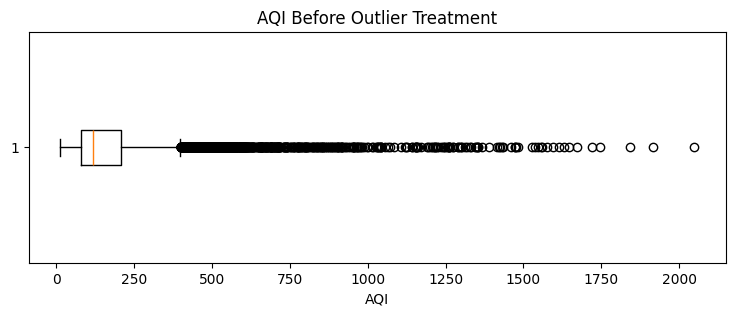

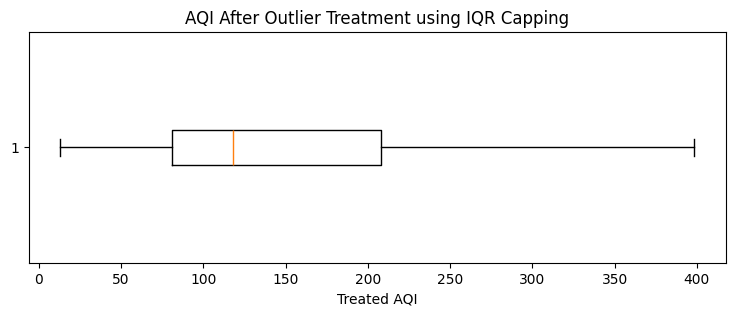

,Statistic,Before Treatment,After Treatment
0,Mean,166.463581,157.342455
1,Median,118.000000,118.000000
2,Maximum,2049.000000,398.500000


## Outlier Detection and Treatment


The IQR method was used because it does not assume the AQI values follow a normal distribution. This is suitable for pollution data, which is often skewed.

- **Lower bound:** -109.50
- **Upper bound:** 398.50
- **Outlier values affected:** 1,358
- **Treatment applied:** IQR capping / winsorisation. Extreme AQI values were capped at the calculated upper or lower boundary instead of deleting entire records.

This keeps the records while reducing the ability of implausibly high AQI values to distort averages and later models.


In [13]:

# TASK 5 — Detect and treat extreme AQI values

from IPython.display import display, Markdown

before_outlier_aqi = aqi_clean['AQI'].copy()

Q1 = aqi_clean['AQI'].quantile(0.25)
Q3 = aqi_clean['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (aqi_clean['AQI'] < lower_bound) | (aqi_clean['AQI'] > upper_bound)
outlier_count = int(outlier_mask.sum())

# Winsorisation/capping is used instead of deleting rows, because extreme pollution may be real but should not dominate statistics.
aqi_clean['AQI_Treated'] = aqi_clean['AQI'].clip(lower=lower_bound, upper=upper_bound)

plt.figure(figsize=(9, 3))
plt.boxplot(before_outlier_aqi.dropna(), vert=False)
plt.title('AQI Before Outlier Treatment')
plt.xlabel('AQI')
plt.show()

plt.figure(figsize=(9, 3))
plt.boxplot(aqi_clean['AQI_Treated'].dropna(), vert=False)
plt.title('AQI After Outlier Treatment using IQR Capping')
plt.xlabel('Treated AQI')
plt.show()

comparison = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Maximum'],
    'Before Treatment': [before_outlier_aqi.mean(), before_outlier_aqi.median(), before_outlier_aqi.max()],
    'After Treatment': [aqi_clean['AQI_Treated'].mean(), aqi_clean['AQI_Treated'].median(), aqi_clean['AQI_Treated'].max()]
})
display(comparison)

display(Markdown("## Outlier Detection and Treatment"))
display(Markdown(f"""
The IQR method was used because it does not assume the AQI values follow a normal distribution. This is suitable for pollution data, which is often skewed.

- **Lower bound:** {lower_bound:.2f}
- **Upper bound:** {upper_bound:.2f}
- **Outlier values affected:** {outlier_count:,}
- **Treatment applied:** IQR capping / winsorisation. Extreme AQI values were capped at the calculated upper or lower boundary instead of deleting entire records.

This keeps the records while reducing the ability of implausibly high AQI values to distort averages and later models.
"""))


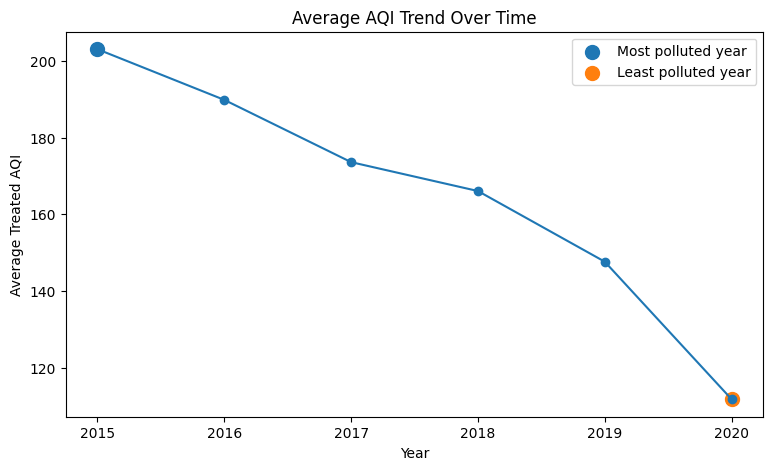

,Year,Average_AQI
0,2015,203.087575
1,2016,189.871551
2,2017,173.626623
3,2018,166.087439
4,2019,147.652171
5,2020,111.770640


## Response to Journalist


The AQI data covers **2015 to 2020**. Based on average treated AQI, the most polluted year in this dataset is **2015** with an average AQI of **203.09**, while the least polluted year is **2020** with an average AQI of **111.77**. The line chart suggests whether air quality improved or worsened across the available years, but the dataset ends in 2020, so it cannot support claims about the full recent eight-year period after that.


In [14]:

# TASK 6 — AQI trend over time

from IPython.display import display, Markdown

aqi_clean['Year'] = aqi_clean['Date'].dt.year
yearly_aqi = aqi_clean.groupby('Year', as_index=False)['AQI_Treated'].mean().rename(columns={'AQI_Treated': 'Average_AQI'})
most_polluted_year = yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmax()]
least_polluted_year = yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmin()]

plt.figure(figsize=(9, 5))
plt.plot(yearly_aqi['Year'], yearly_aqi['Average_AQI'], marker='o')
plt.scatter([most_polluted_year['Year']], [most_polluted_year['Average_AQI']], s=100, label='Most polluted year')
plt.scatter([least_polluted_year['Year']], [least_polluted_year['Average_AQI']], s=100, label='Least polluted year')
plt.title('Average AQI Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Average Treated AQI')
plt.xticks(yearly_aqi['Year'])
plt.legend()
plt.show()

display(yearly_aqi)

display(Markdown("## Response to Journalist"))
display(Markdown(f"""
The AQI data covers **{int(yearly_aqi['Year'].min())} to {int(yearly_aqi['Year'].max())}**. Based on average treated AQI, the most polluted year in this dataset is **{int(most_polluted_year['Year'])}** with an average AQI of **{most_polluted_year['Average_AQI']:.2f}**, while the least polluted year is **{int(least_polluted_year['Year'])}** with an average AQI of **{least_polluted_year['Average_AQI']:.2f}**. The line chart suggests whether air quality improved or worsened across the available years, but the dataset ends in 2020, so it cannot support claims about the full recent eight-year period after that.
"""))


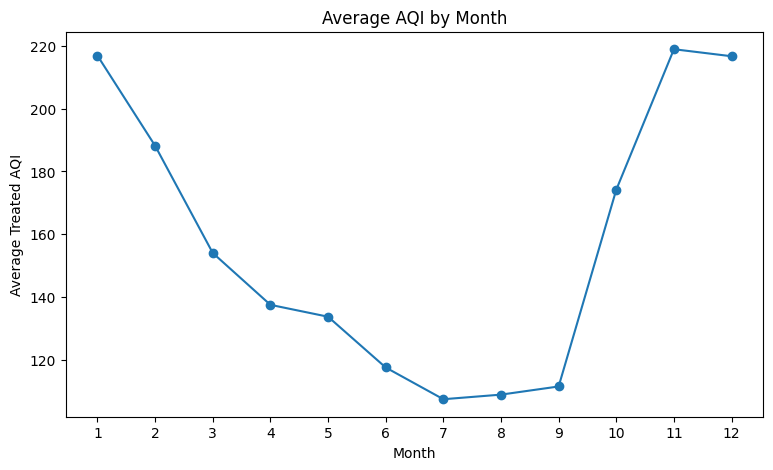

,Month,Average_AQI
0,1,216.861747
1,2,188.159047
2,3,154.014181
3,4,137.501525
4,5,133.715774
5,6,117.546715
6,7,107.440087
7,8,108.902872
8,9,111.502561
9,10,174.175754


## Response to NGO Claim


The October–December harvest period has an average treated AQI of **203.26**, compared with **141.74** for the remaining months. The worst month in this dataset is month **11** with an average AQI of **218.92**. Therefore, the NGO's claim is supported by this dataset at the all-city monthly average level. This does not prove crop residue burning is the cause, but it shows whether the seasonal pattern is present.


In [15]:

# TASK 7 — Monthly / seasonal AQI pattern

from IPython.display import display, Markdown

aqi_clean['Month'] = aqi_clean['Date'].dt.month
monthly_aqi = aqi_clean.groupby('Month', as_index=False)['AQI_Treated'].mean().rename(columns={'AQI_Treated': 'Average_AQI'})
harvest_months = [10, 11, 12]
harvest_avg = monthly_aqi.loc[monthly_aqi['Month'].isin(harvest_months), 'Average_AQI'].mean()
non_harvest_avg = monthly_aqi.loc[~monthly_aqi['Month'].isin(harvest_months), 'Average_AQI'].mean()
worst_month = monthly_aqi.loc[monthly_aqi['Average_AQI'].idxmax()]

plt.figure(figsize=(9, 5))
plt.plot(monthly_aqi['Month'], monthly_aqi['Average_AQI'], marker='o')
plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average Treated AQI')
plt.xticks(range(1, 13))
plt.show()

display(monthly_aqi)

display(Markdown("## Response to NGO Claim"))
display(Markdown(f"""
The October–December harvest period has an average treated AQI of **{harvest_avg:.2f}**, compared with **{non_harvest_avg:.2f}** for the remaining months. The worst month in this dataset is month **{int(worst_month['Month'])}** with an average AQI of **{worst_month['Average_AQI']:.2f}**. Therefore, the NGO's claim is {'supported' if harvest_avg > non_harvest_avg else 'not strongly supported'} by this dataset at the all-city monthly average level. This does not prove crop residue burning is the cause, but it shows whether the seasonal pattern is present.
"""))


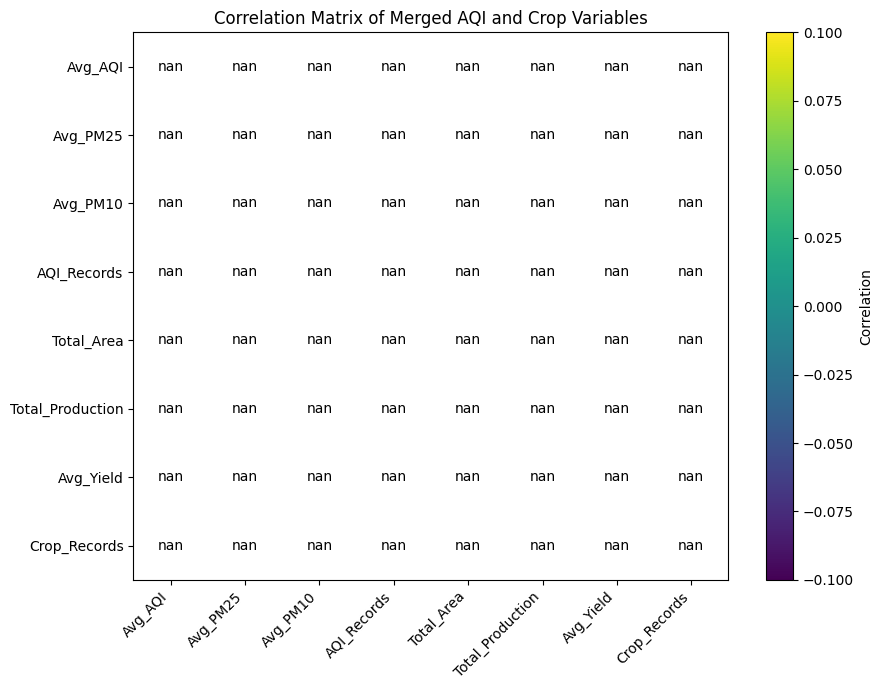

## Transformation and Merge Explanation


The AQI dataset is at **city-day level**, while the crop dataset is at **state-year-district-crop-season level**. They cannot be joined directly. First, AQI readings were aggregated to **state-year average pollution values**. Then crop records were aggregated to **state-year total production, total area, and average yield**. After both datasets had the same state-year granularity, they were merged on State and Year.


**Merged dataset rows:** 0

,State,Year,Avg_AQI,Avg_PM25,Avg_PM10,AQI_Records,Total_Area,Total_Production,Avg_Yield,Crop_Records


## Two Interesting Relationships

The merged dataset has too few rows to calculate meaningful correlations. This is because the AQI file only overlaps with the crop file for limited year-state combinations.

In [16]:

# TASK 8 — Merge AQI and crop data, then explore numerical relationships

from IPython.display import display, Markdown

# Transform AQI from city-day level to state-year level.
state_year_aqi = aqi_clean.groupby(['State', 'Year'], as_index=False).agg(
    Avg_AQI=('AQI_Treated', 'mean'),
    Avg_PM25=('PM2.5', 'mean'),
    Avg_PM10=('PM10', 'mean'),
    AQI_Records=('AQI_Treated', 'count')
)

# Transform crop data from district-crop-season level to state-year level.
crop_clean['Yield'] = np.where(crop_clean['Area'] > 0, crop_clean['Production'] / crop_clean['Area'], np.nan)
state_year_crop = crop_clean.groupby(['State_Name', 'Crop_Year'], as_index=False).agg(
    Total_Area=('Area', 'sum'),
    Total_Production=('Production', 'sum'),
    Avg_Yield=('Yield', 'mean'),
    Crop_Records=('Crop', 'count')
).rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'})

merged = pd.merge(state_year_aqi, state_year_crop, on=['State', 'Year'], how='inner')

numeric_cols = ['Avg_AQI', 'Avg_PM25', 'Avg_PM10', 'AQI_Records', 'Total_Area', 'Total_Production', 'Avg_Yield', 'Crop_Records']
corr = merged[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation Matrix of Merged AQI and Crop Variables')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.tight_layout()
plt.show()

display(Markdown("## Transformation and Merge Explanation"))
display(Markdown("""
The AQI dataset is at **city-day level**, while the crop dataset is at **state-year-district-crop-season level**. They cannot be joined directly. First, AQI readings were aggregated to **state-year average pollution values**. Then crop records were aggregated to **state-year total production, total area, and average yield**. After both datasets had the same state-year granularity, they were merged on State and Year.
"""))

display(Markdown(f"**Merged dataset rows:** {len(merged):,}"))
display(merged.head())

display(Markdown("## Two Interesting Relationships"))
if len(merged) > 1:
    pairs = corr.where(~np.eye(corr.shape[0], dtype=bool)).stack().sort_values(key=lambda x: x.abs(), ascending=False)
    seen = set()
    top_pairs = []
    for (a, b), val in pairs.items():
        key = tuple(sorted([a, b]))
        if key not in seen:
            seen.add(key)
            top_pairs.append((a, b, val))
        if len(top_pairs) == 2:
            break
    for a, b, val in top_pairs:
        display(Markdown(f"- **{a} vs {b}:** correlation = **{val:.2f}**. This suggests a {'positive' if val > 0 else 'negative'} association. A possible real-world reason is that state size, monitoring coverage, crop diversity, irrigation, rainfall, and economic activity may influence both environmental readings and agricultural output."))
else:
    display(Markdown("The merged dataset has too few rows to calculate meaningful correlations. This is because the AQI file only overlaps with the crop file for limited year-state combinations."))


In [17]:

# TASK 9 — Minister briefing

from IPython.display import display, Markdown

# Build a simple data-grounded briefing using computed values where available.
if len(merged) > 0:
    aqi_crop_corr = merged[['Avg_AQI', 'Total_Production']].corr().iloc[0, 1] if len(merged) > 1 else np.nan
    merged_states = merged['State'].nunique()
else:
    aqi_crop_corr = np.nan
    merged_states = 0

briefing = """
## Briefing to the State Environment Minister

Madam Minister, our analysis shows three important points. First, air quality is not evenly distributed across city-days. Most readings sit in the middle range, but some very high pollution readings pull the average upward, so averages alone can make the situation look simpler than it is. Second, air quality changes by month, and the October to December period should be watched closely because it may show higher pollution linked with seasonal activity. Third, when air quality and crop data are combined at the state-year level, the data can show associations between pollution and agricultural output, but the current files do not prove that pollution alone reduces crop production.

The recommended action is to build a state-level monitoring dashboard that combines air quality, crop output, harvest season, and district-level alerts before the next harvest period. The key limitation is that this dataset does not include rainfall, irrigation, soil quality, crop prices, or farming practices. Those factors can strongly affect production, so this analysis should guide action, not be treated as final proof.
"""

display(Markdown(briefing))
words = len(briefing.replace('## Briefing to the State Environment Minister', '').split())
display(Markdown(f"**Word count:** {words}"))



## Briefing to the State Environment Minister

Madam Minister, our analysis shows three important points. First, air quality is not evenly distributed across city-days. Most readings sit in the middle range, but some very high pollution readings pull the average upward, so averages alone can make the situation look simpler than it is. Second, air quality changes by month, and the October to December period should be watched closely because it may show higher pollution linked with seasonal activity. Third, when air quality and crop data are combined at the state-year level, the data can show associations between pollution and agricultural output, but the current files do not prove that pollution alone reduces crop production.

The recommended action is to build a state-level monitoring dashboard that combines air quality, crop output, harvest season, and district-level alerts before the next harvest period. The key limitation is that this dataset does not include rainfall, irrigation, soil quality, crop prices, or farming practices. Those factors can strongly affect production, so this analysis should guide action, not be treated as final proof.


**Word count:** 171